In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import pickle

# Problem Statement
### Using the dataset collected from the class survey form, perform Simple Linear Regression analysis to determine whether:
- CIA percentage can predict GPA
- Attendance percentage can predict GPA


# Task 1

### Part A: Data Collection and Preprocessing

1. Load the dataset using Pandas


In [82]:
# Loading the dataset

data = pd.read_csv("Student Awareness Survey.csv")

2. Display the first 5 rows

In [83]:
# Displaying the first 5 rows

data.head()

,Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester
0,69,3.40,98
1,75,3.69,95
2,82,3.41,95
3,91,3.60,92
4,70,3.54,93


3. Check dataset dimensions

In [84]:
# Checking dataset dimensions

data.shape

(50, 3)

The dataset has 50 rows and 3 columns

4. Identify missing values

In [85]:
# Checking for missing values

data.isnull().sum() 

Your CIA % of last semester                     0
Your GPA of last semester                       0
Your maximum attendance % till last semester    0
dtype: int64

5. Remove or handle null values


In [86]:
# There weren't any null/missing values in the dataset, as seen from the code executed above.

6. Convert required columns into numerical datatype

In [87]:
# Checking basic info, including non-null counts and data types

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Your CIA % of last semester                   50 non-null     str    
 1   Your GPA of last semester                     50 non-null     float64
 2   Your maximum attendance % till last semester  50 non-null     str    
dtypes: float64(1), str(2)
memory usage: 1.5 KB


CIA % and attendance % are being treated as string values.

In [88]:
data.describe()

,Your GPA of last semester
count,50.000000
mean,3.497000
std,0.690865
min,2.740000
25%,3.305000
50%,3.400000
75%,3.600000
max,8.000000


Only GPA is being treated as a float value, the rest need to be converted. For that, standardization will be required first as there are inconsistencies.

In [89]:
data["Your maximum attendance % till last semester"]

0         98
1         95
2         95
3         92
4         93
5         98
6         94
7         85
8         90
9         93
10        95
11        95
12        95
13       85%
14       100
15        85
16        88
17      91 %
18       100
19     96.54
20        95
21        90
22       95%
23       98%
24    94.70%
25        93
26        96
27        93
28        99
29        90
30       100
31        92
32       95%
33        94
34       89%
35        88
36        97
37        95
38       100
39       89%
40        96
41        96
42        92
43       93%
44        95
45        95
46        97
47       97%
48        90
49        94
Name: Your maximum attendance % till last semester, dtype: str

In [90]:
# Getting rid of the % sign and converting the column to float type

data["Your maximum attendance % till last semester"] = data["Your maximum attendance % till last semester"].str.rstrip("%").astype(float)

In [91]:
data.info() # verifying it

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Your CIA % of last semester                   50 non-null     str    
 1   Your GPA of last semester                     50 non-null     float64
 2   Your maximum attendance % till last semester  50 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.4 KB


In [92]:
data["Your CIA % of last semester"]

0         69
1         75
2         82
3         91
4         70
5         75
6         74
7         68
8         73
9         79
10        72
11        80
12        78
13         7
14        70
15        60
16        68
17      71 %
18        64
19     71.78
20        70
21        63
22       76%
23       83%
24       80%
25        72
26        70
27        70
28        71
29        77
30        80
31        80
32       80%
33        70
34       85%
35        71
36        68
37        67
38        72
39      65 %
40        76
41      75.2
42     69.78
43    71.11%
44     79.56
45        75
46        70
47       62%
48       66%
49        63
Name: Your CIA % of last semester, dtype: str

In [93]:
# Getting rid of the % sign and converting the column to float type again

data["Your CIA % of last semester"] = data["Your CIA % of last semester"].str.rstrip("%").astype(float)

In [94]:
data.info() # verifying again

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Your CIA % of last semester                   50 non-null     float64
 1   Your GPA of last semester                     50 non-null     float64
 2   Your maximum attendance % till last semester  50 non-null     float64
dtypes: float64(3)
memory usage: 1.3 KB


In [95]:
data[["Your maximum attendance % till last semester", "Your CIA % of last semester"]]

,Your maximum attendance % till last semester,Your CIA % of last semester
0,98.00,69.00
1,95.00,75.00
2,95.00,82.00
3,92.00,91.00
4,93.00,70.00
5,98.00,75.00
6,94.00,74.00
7,85.00,68.00
8,90.00,73.00
9,93.00,79.00


7. Remove duplicate records if present

In [96]:
# Checking for duplicate rows

data.duplicated().sum() 

np.int64(0)

There are no duplicate values

8. Generate statistical summary

In [97]:
data.describe() # getting statistical summary

,Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester
count,50.000000,50.000000,50.000000
mean,71.508600,3.497000,93.824800
std,11.247756,0.690865,3.852926
min,7.000000,2.740000,85.000000
25%,69.195000,3.305000,92.000000
50%,71.445000,3.400000,95.000000
75%,76.750000,3.600000,96.000000
max,91.000000,8.000000,100.000000


Average CIA % of the class is 71.50 %, with the lowest being 7 % and the highest being 91 %.

Average GPA % of the class is 3.49, with the lowest being 2.74 and the highest being 8, but this could be an outlier, on the assumption that the user filled it on the basis of CGPA (10 point scale) and not GPA (4 point scale), as the median distributions are around the ranges of 3.3, 3.4 and 3.6.

Average attendance % of the class is 93.82 %, with the lowest being 85 % and the highest being 100 %.


In [98]:
data = data[data["Your GPA of last semester"] != 8] # removing rows with GPA = 8, since it's an outlier

In [99]:
data.describe() # verifying it

,Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester
count,49.000000,49.000000,49.000000
mean,72.825102,3.405102,94.004898
std,6.378355,0.237023,3.674066
min,60.000000,2.740000,85.000000
25%,69.780000,3.300000,92.000000
50%,71.780000,3.400000,95.000000
75%,77.000000,3.600000,96.000000
max,91.000000,3.900000,100.000000


9. Select appropriate dependent and independent variables

In [100]:
# Changing column names first for better readability

renamed_columns = {
    "Your CIA % of last semester": "CIA_Percentage",
    "Your GPA of last semester": "GPA",
    "Your maximum attendance % till last semester": "Attendance_Percentage"
}

data = data.rename(columns = renamed_columns)
data.head()

,CIA_Percentage,GPA,Attendance_Percentage
0,69.0,3.40,98.0
1,75.0,3.69,95.0
2,82.0,3.41,95.0
3,91.0,3.60,92.0
4,70.0,3.54,93.0


GPA - dependent variable, as we're trying to predict if CIA_Percentage and Attendance_Percentage can predict GPA.

CIA_Percentage and Attendance_Percentage - independent variables.

Experiment 1: Whether CIA percentage can predict GPA; GPA - dependent, CIA_Percentage - independent

Experiment 2: Whether Attendance percentage can predict GPA; GPA - dependent, Attendence_Percentage - independent.

### Experiment 1:

Independent Variable (X):

- CIA Percentage

Dependent Variable (Y):

- GPA


### Part B (Exp 1): Simple Linear Regression using Scikit-learn

In [111]:
# Setting the independent and dependent variables

X1 = data[["CIA_Percentage"]]
y1 = data["GPA"]

In [112]:
# Splitting the dataset into training (80%) and testing (20%) sets, meaning that the model will be trained on 80% of the data and evaluated on the remaining 20%. The random_state parameter is set to 42 to ensure reproducibility of the results.

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size = 0.2, random_state = 42)

In [113]:
lr1 = LinearRegression() # creating an instance of the model
lr1.fit(X_train1, y_train1) # trains the data (80% of the data), where X_train trains on the features and y_train trains on the target variable

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['CIA_Percentage']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.483
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [114]:
y_pred1 = lr1.predict(X_test1) # making predictions on the test set (20% of the data) using the trained model

In [115]:
comparison_cia_percentage = pd.DataFrame({
    "Actual": y_test1.values,
    "Predicted": y_pred1
})

comparison_cia_percentage.head()

,Actual,Predicted
0,3.49,3.379357
1,3.69,3.379357
2,2.74,3.328159
3,3.66,3.443356
4,3.11,3.302559


In [116]:
sample_input_cia = pd.DataFrame([[72]], columns = ["CIA_Percentage"])
sample_prediction_cia = lr1.predict(sample_input_cia)
sample_prediction_cia

array([3.40495676])

For a CIA % of 72, it predicted GPA to b 3.40.

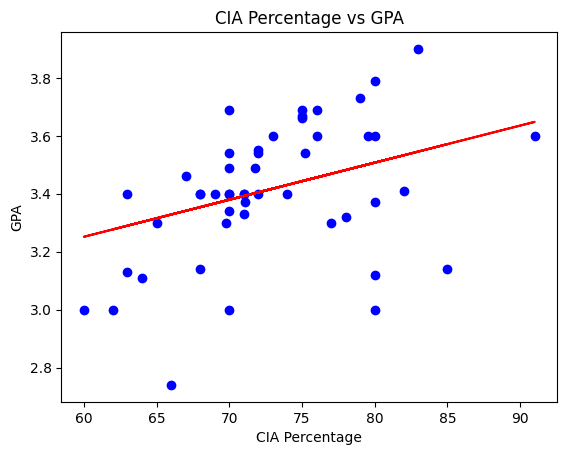

In [ ]:
plt.scatter(X1, y1, color = "blue")

plt.plot(X_train1, lr1.predict(X_train1), color = "red")
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("CIA Percentage vs GPA")
plt.show() 

The actual data points are represented in blue, while the red line is the linear regression line. The training features (X_train) and the predictions made by the model on X_train are used to plot the line in red.

In [118]:
mae = mean_absolute_error(y_test1, y_pred1)
mse = mean_squared_error(y_test1, y_pred1)
r2 = r2_score(y_test1, y_pred1)

print("Model evaluation metrics: ")
print("Mean Absolute Error (MAE): ", mae)
print("Mean Squared Error (MSE): ", mse)
print("R-squared (R2) Score: ", r2)

Model evaluation metrics: 
Mean Absolute Error (MAE):  0.20128077169804856
Mean Squared Error (MSE):  0.06970189658295683
R-squared (R2) Score:  0.17711210116456322


MAE - the model's predicted GPA is off by about 0.20 grade points, from a student's actual GPA.

MSE - the model made mistakes, but the majority of those mistakes are small. There weren't any massive guessing errors.

R2 score - 17.7% of the pattern in student GPAs can be explained by their CIA %s. The remaining is likely due to other factors.

In [119]:
print("Slope: ", lr1.coef_[0])
print("Intercept: ", lr1.intercept_)

Slope:  0.01279967845914644
Intercept:  2.483379907389372


The slope shows how much the GPA is expected to change for a one-unit increase in CIA %.

The intercept shows the predicted GPA when CIA % is 0.

### Part C (Exp 1): Manual Computation using Ordinary Least Squares (OLS)

In [ ]:
# Extract values from your training set as arrays

x_i = X_train1["CIA_Percentage"].values
y_i = y_train1.values

In [ ]:
# Calculate the means (x_bar and y_bar)

x_bar = np.mean(x_i)
y_bar = np.mean(y_i)

In [ ]:
# Computing the slope (m); Numerator: Sum of (x_i - x_bar) * (y_i - y_bar)

numerator = np.sum((x_i - x_bar) * (y_i - y_bar))

In [ ]:
# Denominator: Sum of (x_i - x_bar)^2

denominator = np.sum((x_i - x_bar) ** 2)

m = numerator / denominator

In [ ]:
# Computing the intercept

b = y_bar - (m * x_bar)

In [126]:
print("Manual Slope (m):", m)
print("Manual Intercept (b):", b)

Manual Slope (m): 0.012799678459146441
Manual Intercept (b): 2.4833799073893714


In [128]:
x_test_values = X_test1["CIA_Percentage"].values
y_hat_manual = (m * x_test_values) + b
comparison_df = pd.DataFrame({
    "Actual (y)": y_test1.values,
    "Scikit-Learn Prediction": y_pred1,  # from your lr.predict(X_test1)
    "Manual OLS Prediction": y_hat_manual,
    "Difference": y_pred1 - y_hat_manual
})
comparison_df.head()

,Actual (y),Scikit-Learn Prediction,Manual OLS Prediction,Difference
0,3.49,3.379357,3.379357,0.000000e+00
1,3.69,3.379357,3.379357,0.000000e+00
2,2.74,3.328159,3.328159,0.000000e+00
3,3.66,3.443356,3.443356,4.440892e-16
4,3.11,3.302559,3.302559,0.000000e+00


There isn't a difference between the predictions made using Scikit Linear Regression and Manual Computation using OLS.

Creating a pickle file for experiment 1:

In [131]:
cia_weights = {
    "slope": lr1.coef_[0],
    "intercept": lr1.intercept_
}

with open("linear_regression_weights_cia.pkl", "wb") as f:
    pickle.dump(cia_weights, f)

print("Experiment 1 weights saved successfully!")

Experiment 1 weights saved successfully!


In [132]:
with open("linear_regression_weights_cia.pkl", "rb") as f:
    loaded_cia_weights = pickle.load(f)

m_loaded = loaded_cia_weights["slope"]
b_loaded = loaded_cia_weights["intercept"]

sample_cia = 75
predicted_gpa = (m_loaded * sample_cia) + b_loaded

print(f"Loaded Slope: {m_loaded}")
print(f"Loaded Intercept: {b_loaded}")
print(f"Predicted GPA for {sample_cia}% CIA using loaded weights: {predicted_gpa}")

Loaded Slope: 0.01279967845914644
Loaded Intercept: 2.483379907389372
Predicted GPA for 75% CIA using loaded weights: 3.443355791825355


### Experiment 12:

Independent Variable (X):

- Attendance Percentage

Dependent Variable (Y):

- GPA


### Part B (Exp 2): Simple Linear Regression using Scikit-learn

In [133]:
# Setting the independent and dependent variables

X2 = data[["Attendance_Percentage"]]
y2 = data["GPA"]

In [135]:
# Splitting the dataset into training (80%) and testing (20%) sets, meaning that the model will be trained on 80% of the data and evaluated on the remaining 20%. The random_state parameter is set to 42 to ensure reproducibility of the results.

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 42)

In [136]:
lr2 = LinearRegression() # creating an instance of the model
lr2.fit(X_train2, y_train2) # trains the data (80% of the data), where X_train trains on the features and y_train trains on the target variable

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.02]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Attendance_Percentage']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.141
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [137]:
y_pred2 = lr2.predict(X_test2) # making predictions on the test set (20% of the data) using the trained model

In [138]:
comparison_attendance_percentage = pd.DataFrame({
    "Actual": y_test2.values,
    "Predicted": y_pred2
})

comparison_attendance_percentage.head()

,Actual,Predicted
0,3.49,3.581648
1,3.69,3.508418
2,2.74,3.337548
3,3.66,3.459598
4,3.11,3.581648


In [139]:
sample_input_attendance = pd.DataFrame([[90]], columns = ["Attendance_Percentage"])
sample_prediction_attendance = lr2.predict(sample_input_attendance)
sample_prediction_attendance

array([3.33754848])

For an attendance % of 90, it predicted GPA to b 3.33.

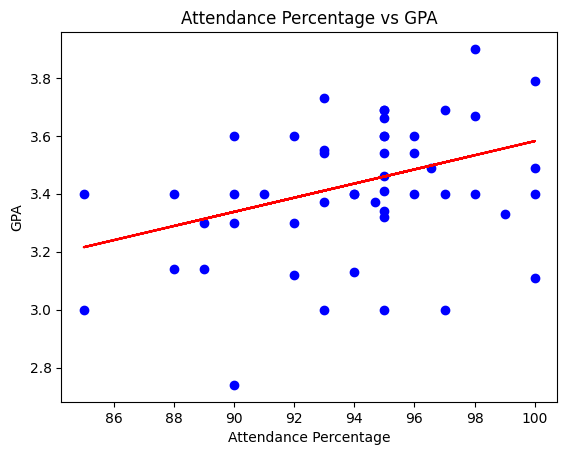

In [140]:
plt.scatter(X2, y2, color = "blue")

plt.plot(X_train2, lr2.predict(X_train2), color = "red")
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Attendance Percentage vs GPA")
plt.show() 

In [141]:
mae = mean_absolute_error(y_test2, y_pred2)
mse = mean_squared_error(y_test2, y_pred2)
r2 = r2_score(y_test2, y_pred2)

print("Model evaluation metrics: ")
print("Mean Absolute Error (MAE): ", mae)
print("Mean Squared Error (MSE): ", mse)
print("R-squared (R2) Score: ", r2)

Model evaluation metrics: 
Mean Absolute Error (MAE):  0.2524852162711263
Mean Squared Error (MSE):  0.09224976831176358
R-squared (R2) Score:  -0.08908396665757912


MAE - the model's predicted GPA is off by about 0.25 grade points, from a student's actual GPA.

MSE - the model made more severe mistakes, with some predictions being quite far off.

R2 score - the negative score implies that the model is performing worse than a horizontal line (which would have an R2 score of 0). This suggests that the model is not capturing the relationship between Attendance Percentage and GPA effectively, and there may be other factors influencing GPA that are not accounted for in this model.

In [143]:
print("Slope: ", lr2.coef_[0])
print("Intercept: ", lr2.intercept_)

Slope:  0.02440993165985645
Intercept:  1.1406546355016682


The slope shows how much the GPA is expected to change for a one-unit increase in Attendance %.

The intercept shows the predicted GPA when Attendance % is 0.

### Part C (Exp 2): Manual Computation using Ordinary Least Squares (OLS)

In [155]:
# Extract values from your training set as arrays

x_i = X_train2["Attendance_Percentage"].values
y_i = y_train2.values

In [ ]:
# Calculate the means (x_bar and y_bar)

x_bar = np.mean(x_i)
y_bar = np.mean(y_i)

In [ ]:
# Computing the slope (m); Numerator: Sum of (x_i - x_bar) * (y_i - y_bar)

numerator = np.sum((x_i - x_bar) * (y_i - y_bar))

In [ ]:
# Denominator: Sum of (x_i - x_bar)^2

denominator = np.sum((x_i - x_bar) ** 2)

m = numerator / denominator

In [ ]:
# Computing intercept

b = y_bar - (m * x_bar)

In [150]:
print("Manual Slope (m):", m)
print("Manual Intercept (b):", b)

Manual Slope (m): 0.024409931659856447
Manual Intercept (b): 1.1406546355016687


In [151]:
x_test_values = X_test2["Attendance_Percentage"].values
y_hat_manual = (m * x_test_values) + b
comparison_df = pd.DataFrame({
    "Actual (y)": y_test2.values,
    "Scikit-Learn Prediction": y_pred2,  # from your lr.predict(X_test2)
    "Manual OLS Prediction": y_hat_manual,
    "Difference": y_pred2 - y_hat_manual
})
comparison_df.head()

,Actual (y),Scikit-Learn Prediction,Manual OLS Prediction,Difference
0,3.49,3.581648,3.581648,0.0
1,3.69,3.508418,3.508418,0.0
2,2.74,3.337548,3.337548,0.0
3,3.66,3.459598,3.459598,0.0
4,3.11,3.581648,3.581648,0.0


There isn't a difference between the predictions made using Scikit Linear Regression and Manual Computation using OLS.

Creating a pickle file for experiment 2:

In [152]:
attendance_weights = {
    "slope": lr2.coef_[0],
    "intercept": lr2.intercept_
}

with open("linear_regression_weights_attendance.pkl", "wb") as f:
    pickle.dump(attendance_weights, f)

print("Experiment 2 weights saved successfully!")

Experiment 2 weights saved successfully!


In [154]:
with open("linear_regression_weights_attendance.pkl", "rb") as f:
    loaded_attendance_weights = pickle.load(f)

m_loaded = loaded_attendance_weights["slope"]
b_loaded = loaded_attendance_weights["intercept"]

sample_attendance = 75
predicted_gpa = (m_loaded * sample_attendance) + b_loaded

print(f"Loaded Slope: {m_loaded}")
print(f"Loaded Intercept: {b_loaded}")
print(f"Predicted GPA for {sample_attendance}% Attendance using loaded weights: {predicted_gpa}")

Loaded Slope: 0.02440993165985645
Loaded Intercept: 1.1406546355016682
Predicted GPA for 75% Attendance using loaded weights: 2.971399509990902


### Final Observations & Inference

There is no difference between the predictions made by the Scikit-Learn Linear Regression method and the Ordinary Least Square method.

Experiment 1 (CIA % as Predictor): It achieved the lowest average error (MAE: 0.20), showed no wild prediction errors (MSE: 0.069), and gave a positive R2 score of 0.177.

Experiment 2 (Attendance % as Predictor): This model failed to find a reliable linear pattern. It resulted in higher errors (MAE: 0.25, MSE: 0.092) and a negative R2 score of -0.089, meaning a straight trend line performed worse than just guessing the class average.